# Exploratory Data Analysis — Olist Brazilian E-Commerce

**Source:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Kaggle).

This dataset contains ~100k orders placed on the Olist marketplace between 2016 and 2018, covering
customers, orders, order items, payments, product catalog, sellers, geolocation, and customer reviews
across multiple Brazilian states. It is a normalized, multi-table relational dataset loaded into a local
DuckDB warehouse (`data/olist.duckdb`) for this analysis.

This notebook provides an initial exploratory pass over the data: table sizes, data completeness,
revenue and order trends, category and geographic breakdowns, the order-status funnel, and the
distribution of customer review scores. Pre-aggregated marts in `data/processed/` are used where
available; ad-hoc queries are run directly against DuckDB otherwise.


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

con = duckdb.connect('../data/olist.duckdb', read_only=True)


## 1. Dataset Overview — Row Counts per Table

In [2]:
tables = ['customers', 'orders', 'order_items', 'order_payments',
          'order_reviews', 'products', 'product_category_translation',
          'sellers', 'geolocation']

counts = {t: con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0] for t in tables}
counts_df = pd.DataFrame(list(counts.items()), columns=['table', 'row_count']).sort_values('row_count', ascending=False)
counts_df


,table,row_count
8,geolocation,738332
2,order_items,112650
3,order_payments,103886
0,customers,99441
1,orders,99441
4,order_reviews,99224
5,products,32951
7,sellers,3095
6,product_category_translation,73


**Interpretation.** The `orders` table anchors the schema at roughly 99k rows, one per purchase
transaction. `order_items` and `order_payments` are larger because a single order can contain multiple
line items or be split across multiple payment installments/methods. `geolocation` is by far the largest
table, reflecting many latitude/longitude records per zip-code prefix rather than a one-row-per-address
structure. `order_reviews` is close to the order count, indicating that most orders receive a single review.


## 2. Missing-Value Overview

In [3]:
missing_orders = con.execute('''
    SELECT
        SUM(CASE WHEN order_approved_at IS NULL THEN 1 ELSE 0 END) AS missing_approved_at,
        SUM(CASE WHEN order_delivered_carrier_date IS NULL THEN 1 ELSE 0 END) AS missing_carrier_date,
        SUM(CASE WHEN order_delivered_customer_date IS NULL THEN 1 ELSE 0 END) AS missing_delivered_date,
        SUM(CASE WHEN delivery_delay_days IS NULL THEN 1 ELSE 0 END) AS missing_delivery_delay,
        COUNT(*) AS total_orders
    FROM orders
''').fetchdf()
missing_orders


,missing_approved_at,missing_carrier_date,missing_delivered_date,missing_delivery_delay,total_orders
0,160.0,1783.0,2965.0,2965.0,99441


In [4]:
status_of_missing_delivery = con.execute('''
    SELECT order_status, COUNT(*) AS n_orders
    FROM orders
    WHERE order_delivered_customer_date IS NULL
    GROUP BY order_status
    ORDER BY n_orders DESC
''').fetchdf()
status_of_missing_delivery


,order_status,n_orders
0,shipped,1107
1,canceled,619
2,unavailable,609
3,invoiced,314
4,processing,301
5,delivered,8
6,created,5
7,approved,2


In [5]:
missing_reviews = con.execute('''
    SELECT
        SUM(CASE WHEN review_comment_title IS NULL THEN 1 ELSE 0 END) AS missing_title,
        SUM(CASE WHEN review_comment_message IS NULL THEN 1 ELSE 0 END) AS missing_message,
        COUNT(*) AS total_reviews
    FROM order_reviews
''').fetchdf()
missing_reviews


,missing_title,missing_message,total_reviews
0,87656.0,58247.0,99224


In [6]:
missing_products = con.execute('''
    SELECT
        SUM(CASE WHEN product_category_name IS NULL THEN 1 ELSE 0 END) AS missing_category,
        SUM(CASE WHEN product_weight_g IS NULL THEN 1 ELSE 0 END) AS missing_weight,
        COUNT(*) AS total_products
    FROM products
''').fetchdf()
missing_products


,missing_category,missing_weight,total_products
0,610.0,2.0,32951


**Interpretation.** Missingness in the `orders` table is concentrated in delivery-related timestamps
and is not random: orders that were never delivered (canceled, still shipped, or unavailable) legitimately
have no `order_delivered_customer_date`, and therefore no `delivery_delay_days`, since that field is
derived from the delivery and estimate dates. This is expected structural missingness rather than a data
quality defect, and it is handled downstream by scoping the delivery-delay analysis to delivered orders
only. Review comment title/message are optional free-text fields in the source survey, so a large share of
nulls there simply reflects customers who left a star rating without a written comment. A small number of
products are missing category or weight information, likely due to incomplete seller-side catalog entries;
this affects a small share of the catalog and is noted here rather than imputed.


## 3. Revenue and Order-Count Trends Over Time (Monthly)

In [7]:
monthly = pd.read_parquet('../data/processed/monthly_revenue_trend.parquet')
monthly = monthly.sort_values(monthly.columns[0])
monthly.head()


,order_purchase_month,order_count,total_revenue,avg_order_value
0,2016-10,265,46566.71,175.72
1,2016-12,1,19.62,19.62
2,2017-01,750,127545.67,170.06
3,2017-02,1653,271298.65,164.13
4,2017-03,2546,414369.39,162.75


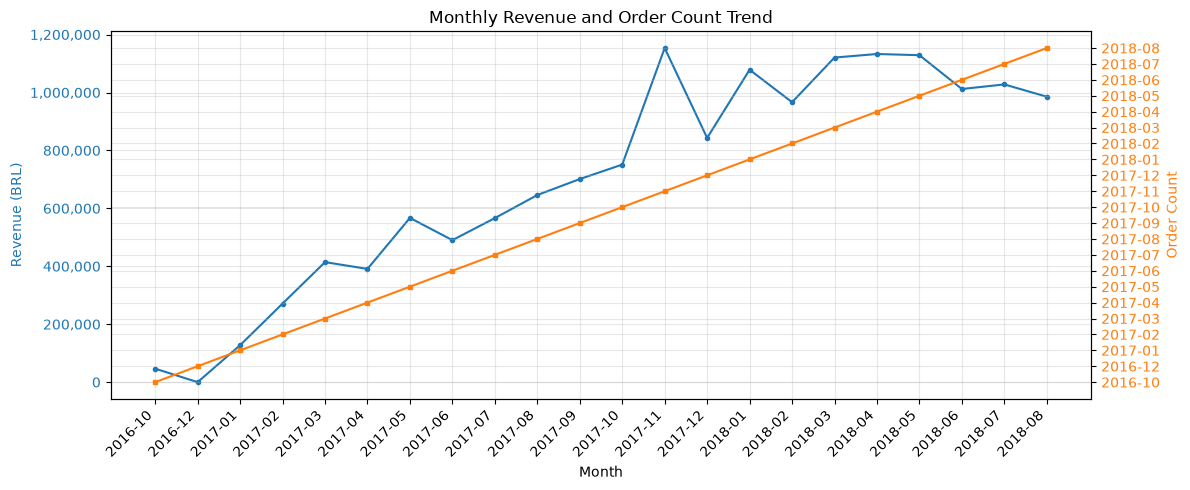

In [8]:
month_col = monthly.columns[0]
revenue_col = [c for c in monthly.columns if 'revenue' in c.lower()][0]
orders_col = [c for c in monthly.columns if 'order' in c.lower()]
orders_col = orders_col[0] if orders_col else None

fig, ax1 = plt.subplots(figsize=(12, 5))
x = monthly[month_col].astype(str)
ax1.plot(x, monthly[revenue_col], color='tab:blue', marker='o', markersize=3, label='Revenue')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (BRL)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:,.0f}'))
step = max(1, len(x) // 15)
ax1.set_xticks(range(0, len(x), step))
ax1.set_xticklabels(x[::step], rotation=45, ha='right')

if orders_col:
    ax2 = ax1.twinx()
    ax2.plot(x, monthly[orders_col], color='tab:orange', marker='s', markersize=3, label='Order Count')
    ax2.set_ylabel('Order Count', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Monthly Revenue and Order Count Trend')
fig.tight_layout()
plt.show()


**Interpretation.** Revenue and order volume track each other closely month over month, which is
expected given a relatively stable average order value over the observed period. The series shows the
platform's growth trajectory from a low base in early 2017 to a peak in late 2017/2018, consistent with
Olist's known rapid scale-up during this window, before tapering at the very end of the series where the
most recent month(s) are typically partial (in-progress) and should not be read as a demand drop.


## 4. Category Breakdown — Top Categories by Revenue and Order Count

In [9]:
cat_df = pd.read_parquet('../data/processed/revenue_by_category.parquet')
cat_df.head()


,category,total_revenue,line_items
0,health_beauty,1412140.48,9462
1,watches_gifts,1264697.30,5859
2,bed_bath_table,1225948.49,10953
3,sports_leisure,1118166.98,8431
4,computers_accessories,1032834.45,7644


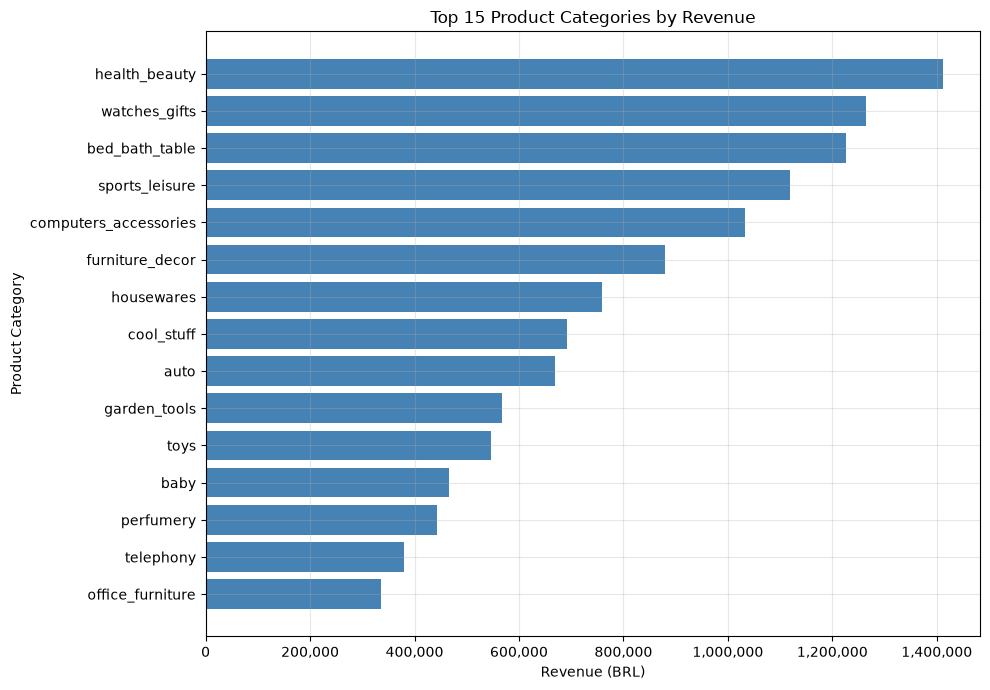

In [10]:
cat_col = [c for c in cat_df.columns if 'categ' in c.lower()][0]
rev_col = [c for c in cat_df.columns if 'revenue' in c.lower()][0]
cnt_col = [c for c in cat_df.columns if 'order' in c.lower() or 'count' in c.lower()]
cnt_col = cnt_col[0] if cnt_col else None

top_rev = cat_df.sort_values(rev_col, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_rev[cat_col][::-1], top_rev[rev_col][::-1], color='steelblue')
ax.set_xlabel('Revenue (BRL)')
ax.set_ylabel('Product Category')
ax.set_title('Top 15 Product Categories by Revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:,.0f}'))
plt.tight_layout()
plt.show()


In [11]:
if cnt_col:
    top_cnt = cat_df.sort_values(cnt_col, ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top_cnt[cat_col][::-1], top_cnt[cnt_col][::-1], color='darkorange')
    ax.set_xlabel('Order Count')
    ax.set_ylabel('Product Category')
    ax.set_title('Top 15 Product Categories by Order Count')
    plt.tight_layout()
    plt.show()


**Interpretation.** Revenue is concentrated in a relatively small number of categories — durable and
higher-ticket goods (e.g. furniture/home decor, health & beauty, and electronics-adjacent categories)
dominate the revenue ranking even though they do not always lead in raw order count. Categories with high
order counts but comparatively modest revenue point to lower average selling prices and higher purchase
frequency. This split is useful for prioritization: revenue-leading categories merit focus for
margin/logistics investment, while high-volume categories are more relevant to fulfillment capacity
planning.


## 5. Geographic Breakdown — Revenue and Orders by State

In [12]:
state_df = pd.read_parquet('../data/processed/revenue_by_state.parquet')
state_col = [c for c in state_df.columns if 'state' in c.lower()][0]
rev_col_s = [c for c in state_df.columns if 'revenue' in c.lower()][0]
state_df.sort_values(rev_col_s, ascending=False).head(10)


,customer_state,order_count,total_revenue,avg_order_value
0,SP,40500,5770266.19,142.48
1,RJ,12350,2055690.45,166.45
2,MG,11354,1819277.61,160.23
3,RS,5345,861802.40,161.24
4,PR,4923,781919.55,158.83
5,SC,3546,595208.40,167.85
6,BA,3256,591270.60,181.59
7,DF,2080,346146.17,166.42
8,GO,1957,334294.22,170.82
9,ES,1995,317682.65,159.24


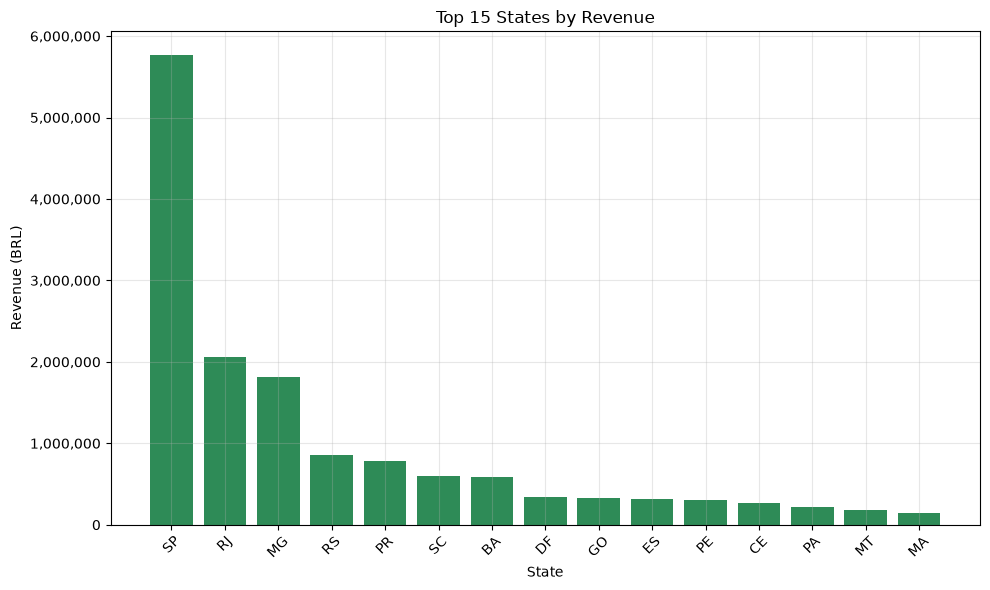

In [13]:
top_states = state_df.sort_values(rev_col_s, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(top_states[state_col], top_states[rev_col_s], color='seagreen')
ax.set_xlabel('State')
ax.set_ylabel('Revenue (BRL)')
ax.set_title('Top 15 States by Revenue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Interpretation.** Revenue is heavily concentrated in São Paulo (SP), consistent with it being
Brazil's most populous and economically dominant state and Olist's home market, followed by a handful of
other large southeastern and southern states (e.g. Rio de Janeiro, Minas Gerais). The long tail of
lower-revenue states suggests either lower population density, weaker logistics coverage, or lower
e-commerce penetration outside the major economic hubs — relevant context for any state-level delivery
performance or expansion analysis.


## 6. Order Status Funnel

In [14]:
funnel = con.execute('''
    SELECT order_status, COUNT(*) AS n_orders
    FROM orders
    GROUP BY order_status
    ORDER BY n_orders DESC
''').fetchdf()
funnel


,order_status,n_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


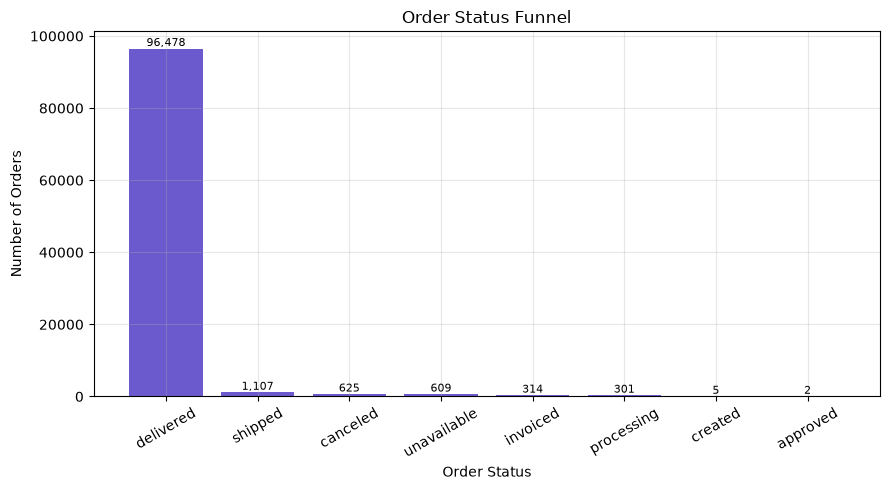

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(funnel['order_status'], funnel['n_orders'], color='slateblue')
ax.set_xlabel('Order Status')
ax.set_ylabel('Number of Orders')
ax.set_title('Order Status Funnel')
for i, v in enumerate(funnel['n_orders']):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Interpretation.** The overwhelming majority of orders reach the `delivered` status, indicating a
healthy fulfillment pipeline overall. Non-delivered statuses (canceled, unavailable, shipped-in-transit at
data cutoff) represent a small minority of the total. Orders still in `shipped`/`processing`/`invoiced`
states at the time the dataset was extracted explain part of the missing delivery-date values noted in
Section 2, since those orders had not yet completed their lifecycle when the snapshot was taken.


## 7. Review Score Distribution

In [16]:
review_dist = con.execute('''
    SELECT review_score, COUNT(*) AS n_reviews
    FROM order_reviews
    GROUP BY review_score
    ORDER BY review_score
''').fetchdf()
review_dist


,review_score,n_reviews
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


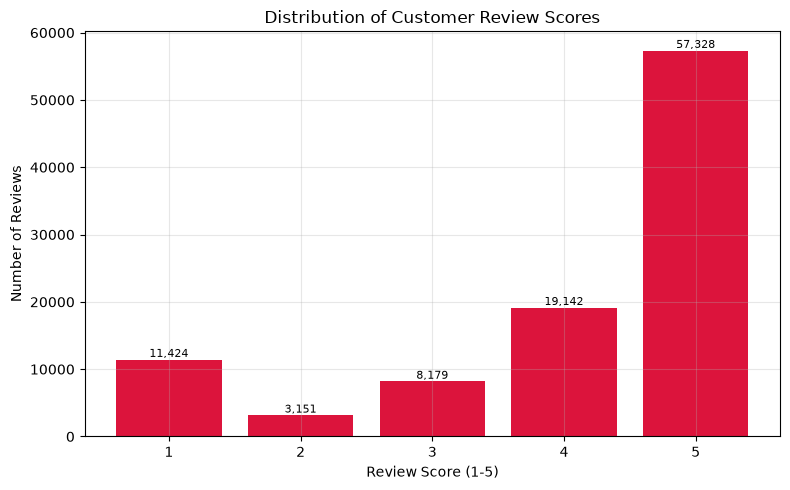

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(review_dist['review_score'], review_dist['n_reviews'], color='crimson')
ax.set_xlabel('Review Score (1-5)')
ax.set_ylabel('Number of Reviews')
ax.set_title('Distribution of Customer Review Scores')
ax.set_xticks([1, 2, 3, 4, 5])
for x, v in zip(review_dist['review_score'], review_dist['n_reviews']):
    ax.text(x, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


**Interpretation.** The review-score distribution is strongly left-skewed toward 5-star ratings, with
a secondary smaller mass at 1-star. This bimodal-leaning pattern is typical of post-purchase satisfaction
surveys: most transactions go as expected and receive top marks, while a distinct minority of clearly
negative experiences (e.g. late or failed deliveries, damaged goods) produce the lowest score rather than a
middling one. Because the distribution is far from normal, non-parametric methods are more appropriate than
mean-based parametric tests when comparing review scores across groups — this motivates the choice of test
in the statistical analysis notebook that follows.


## Summary

This EDA establishes the shape of the Olist dataset: a moderately sized, well-structured multi-table
warehouse with expected and explainable missingness concentrated in delivery timestamps for
non-delivered orders. Revenue and order volume grew over the observed period, with concentration both by
product category and by state (led by São Paulo). The order funnel is dominated by successfully delivered
orders, and review scores skew positive but retain a meaningful negative tail. These findings motivate the
hypothesis tested in `02_statistical_analysis.ipynb`: whether delivery delay is statistically and
practically associated with lower review scores.
